# Homework 5: Neural Networks on the Census (Adult) Dataset

In this assignment, I build and evaluate a neural network using the census (adult) dataset. The pipeline reuses the encoding/scaling approach from the in-class adult notebook and the Keras/TensorFlow patterns from the May 12 and May 19 in-class notebooks.

**Plan**

1. Load and clean the data, then split into train / validation / test.
2. Build preprocessing (impute, scale numeric, one-hot encode categorical).
3. Train a **baseline MLP** to set a floor.
4. Run **three meaningfully different experiments**, changing **one factor at a time** so I can attribute behavior to specific choices:
    - Experiment 1: Architecture (width, then depth).
    - Experiment 2: Regularization (Dropout, then BatchNorm).
    - Experiment 3: Training setup (learning rate, then early stopping with class weights).
5. Run a **systematic Optuna search** over a tighter hyperparameter space.
6. Train the **final model** on train+val, evaluate on the held-out **test set**, and inspect training/validation behavior.
7. Conclude with a **personal workflow** I can reuse for future neural-network projects.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

import optuna

# reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# quiet logs a bit
tf.get_logger().setLevel('ERROR')
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Load and inspect the data

I read the file the same way I did in the in-class adult notebook: treating `?` as missing, stripping whitespace from `income`, and dropping `fnlwgt` (a survey weight, not predictive) and `education` (redundant with the integer column `educational-num`).

In [2]:
adult = pd.read_csv("Data/adult.csv", na_values=["?", " ?"])

adult["income"] = adult["income"].astype(str).str.strip()
adult["income"] = adult["income"].map({"<=50K": 0, ">50K": 1})

print("shape:", adult.shape)
print()
print("class balance:")
print(adult["income"].value_counts(normalize=True).round(3))
print()
print("missing values:")
print(adult.isna().sum()[adult.isna().sum() > 0])
adult.head()

shape: (48842, 15)

class balance:
income
0    0.761
1    0.239
Name: proportion, dtype: float64

missing values:
workclass         2799
occupation        2809
native-country     857
dtype: int64


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


The target is imbalanced (~76% / 24%), which is important for choosing metrics and later for class weighting. I'll track `accuracy`, `balanced_accuracy`, `f1`, and `roc_auc` because accuracy alone hides minority-class behavior.

## 3. Train / validation / test split and preprocessing

I create three splits up front:

- `train` (64%) for fitting,
- `val` (16%) for tuning architecture / hyperparameters,
- `test` (20%) for the final, held-out evaluation.

The preprocessing is fit **only** on the training data to avoid leakage.

In [3]:
X = adult.drop(["income", "fnlwgt", "education"], axis=1)
y = adult["income"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=SEED
)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("numeric:", numeric_features)
print("categorical:", categorical_features)
print()
print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

numeric: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

train: (31258, 12) val: (7815, 12) test: (9769, 12)


In [4]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# fit on train only, transform all three
X_train_p = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_p   = preprocessor.transform(X_val).astype(np.float32)
X_test_p  = preprocessor.transform(X_test).astype(np.float32)

y_train_p = y_train.astype(np.float32)
y_val_p   = y_val.astype(np.float32)
y_test_p  = y_test.astype(np.float32)

n_features = X_train_p.shape[1]
print("feature vector size after preprocessing:", n_features)

feature vector size after preprocessing: 88


## 4. Helper functions

Everything below uses the same training/evaluation helpers so the experiments are directly comparable.

In [5]:
def compile_and_fit(model, X_tr, y_tr, X_va, y_va,
                    epochs=30, batch_size=256, lr=1e-3,
                    class_weight=None, patience=None, verbose=0):
    """Compile and train a binary-classification keras model with consistent settings."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    cbs = []
    if patience is not None:
        cbs.append(callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                            restore_best_weights=True))
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs, batch_size=batch_size,
        class_weight=class_weight,
        callbacks=cbs,
        verbose=verbose,
    )
    return history


def evaluate_model(model, X, y, threshold=0.5):
    """Return a dict of common binary-classification metrics."""
    probs = model.predict(X, verbose=0).ravel()
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y, preds),
        "balanced_accuracy": balanced_accuracy_score(y, preds),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
        "roc_auc": roc_auc_score(y, probs),
    }


def plot_history(history, title=""):
    """Plot loss and accuracy curves from a keras history."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{title} accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def build_mlp(hidden_units, input_dim, dropout=0.0, l2=0.0,
              batchnorm=False, activation="relu"):
    """Generic MLP builder reused across experiments."""
    reg = regularizers.l2(l2) if l2 > 0 else None
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for units in hidden_units:
        model.add(layers.Dense(units, activation=None, kernel_regularizer=reg))
        if batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    return model


results_log = []  # collect rows of metrics for the comparison table

## 5. Baseline neural network

A small two-hidden-layer MLP with no regularization, Adam @ 1e-3, batch size 256, 20 epochs. This is the floor every experiment has to beat.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,809 (30.50 KB)

 Trainable params: 7,809 (30.50 KB)

 Non-trainable params: 0 (0.00 B)

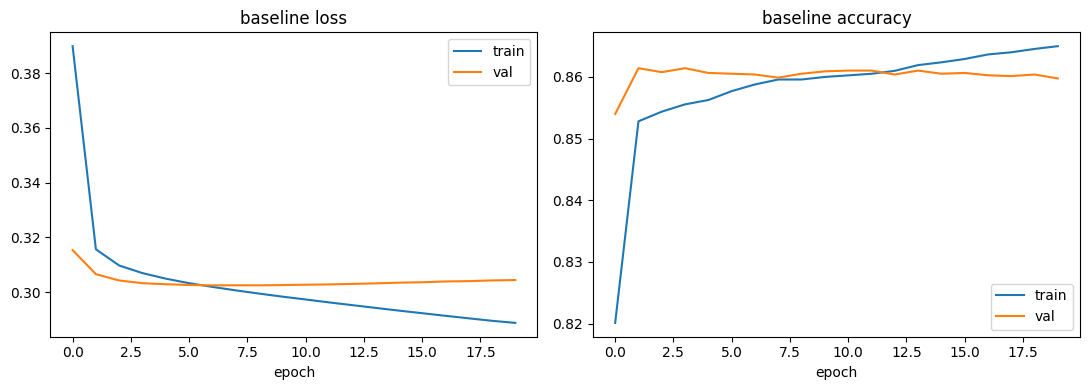

baseline val metrics: {'accuracy': 0.8598, 'balanced_accuracy': 0.7858, 'precision': 0.7368, 'recall': 0.6439, 'f1': 0.6872, 'roc_auc': 0.9154}


In [6]:
keras.utils.set_random_seed(SEED)

baseline = build_mlp(hidden_units=[64, 32], input_dim=n_features)
baseline.summary()

hist_baseline = compile_and_fit(
    baseline, X_train_p, y_train_p, X_val_p, y_val_p,
    epochs=20, batch_size=256, lr=1e-3
)
plot_history(hist_baseline, "baseline")

baseline_val = evaluate_model(baseline, X_val_p, y_val_p)
print("baseline val metrics:", {k: round(v, 4) for k, v in baseline_val.items()})
results_log.append({"experiment": "baseline [64, 32]", **baseline_val})

## 6. Experiment 1 — Architecture (one factor at a time)

I hold everything else (optimizer, learning rate, batch size, epochs) constant and change only the architecture.

- **1a: Wider.** Same depth, more units per layer (`[128, 64]`).
- **1b: Deeper.** Same width as the baseline, more layers (`[64, 64, 32]`).

This lets me isolate the effect of width vs. depth.

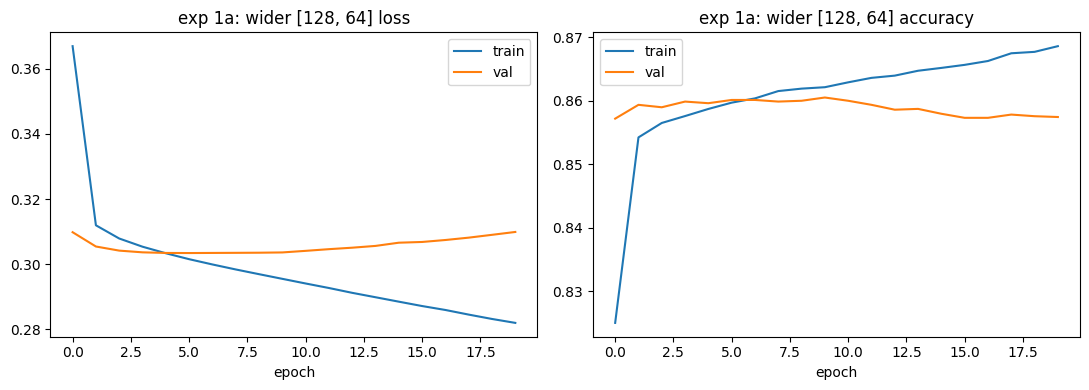

wider val: {'accuracy': 0.8575, 'balanced_accuracy': 0.7769, 'precision': 0.7405, 'recall': 0.6225, 'f1': 0.6764, 'roc_auc': 0.9125}


In [7]:
# 1a — wider
keras.utils.set_random_seed(SEED)
wider = build_mlp(hidden_units=[128, 64], input_dim=n_features)
hist_wider = compile_and_fit(wider, X_train_p, y_train_p, X_val_p, y_val_p,
                              epochs=20, batch_size=256, lr=1e-3)
plot_history(hist_wider, "exp 1a: wider [128, 64]")
wider_val = evaluate_model(wider, X_val_p, y_val_p)
print("wider val:", {k: round(v, 4) for k, v in wider_val.items()})
results_log.append({"experiment": "exp1a wider [128, 64]", **wider_val})

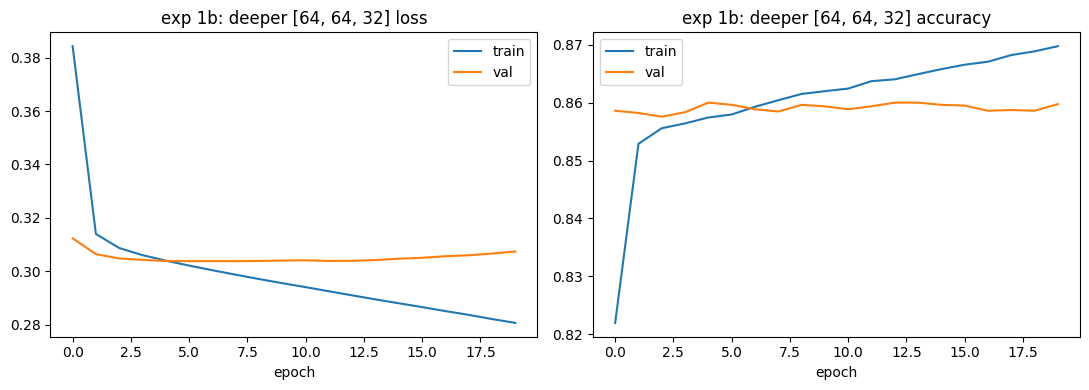

deeper val: {'accuracy': 0.8598, 'balanced_accuracy': 0.7819, 'precision': 0.7431, 'recall': 0.6326, 'f1': 0.6834, 'roc_auc': 0.9135}


In [8]:
# 1b — deeper
keras.utils.set_random_seed(SEED)
deeper = build_mlp(hidden_units=[64, 64, 32], input_dim=n_features)
hist_deeper = compile_and_fit(deeper, X_train_p, y_train_p, X_val_p, y_val_p,
                               epochs=20, batch_size=256, lr=1e-3)
plot_history(hist_deeper, "exp 1b: deeper [64, 64, 32]")
deeper_val = evaluate_model(deeper, X_val_p, y_val_p)
print("deeper val:", {k: round(v, 4) for k, v in deeper_val.items()})
results_log.append({"experiment": "exp1b deeper [64, 64, 32]", **deeper_val})

**Observation.** Comparing the loss curves: the baseline already shows the training loss falling well below validation loss after a few epochs — a hint of overfitting. Making the network wider or deeper increases capacity, and the gap between train and validation usually grows. Width tends to help a little; depth alone (without regularization) often just memorizes faster. This motivates Experiment 2.

## 7. Experiment 2 — Regularization (one factor at a time)

Starting from the wider `[128, 64]` architecture, I add one regularization technique at a time:

- **2a: Dropout.** Add `Dropout(0.3)` after each hidden layer.
- **2b: Dropout + BatchNorm.** Add BatchNorm before activation, keep dropout.

Everything else stays fixed, so I can directly attribute changes to regularization.

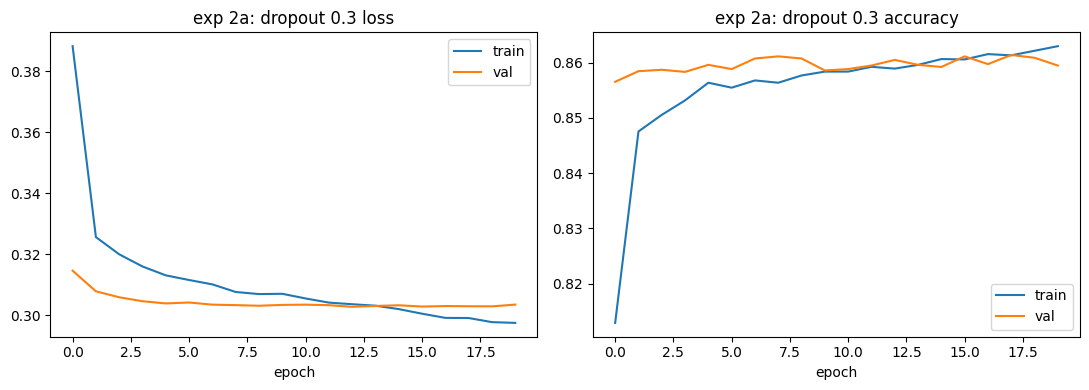

dropout val: {'accuracy': 0.8595, 'balanced_accuracy': 0.777, 'precision': 0.7503, 'recall': 0.6187, 'f1': 0.6782, 'roc_auc': 0.9157}


In [9]:
# 2a — dropout only
keras.utils.set_random_seed(SEED)
dropout_model = build_mlp(hidden_units=[128, 64], input_dim=n_features, dropout=0.3)
hist_dropout = compile_and_fit(dropout_model, X_train_p, y_train_p, X_val_p, y_val_p,
                                epochs=20, batch_size=256, lr=1e-3)
plot_history(hist_dropout, "exp 2a: dropout 0.3")
dropout_val = evaluate_model(dropout_model, X_val_p, y_val_p)
print("dropout val:", {k: round(v, 4) for k, v in dropout_val.items()})
results_log.append({"experiment": "exp2a dropout 0.3", **dropout_val})

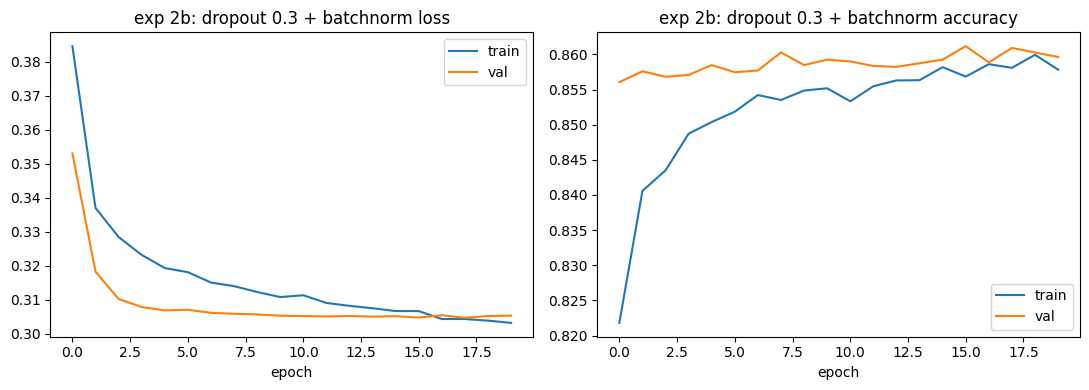

dropout+bn val: {'accuracy': 0.8596, 'balanced_accuracy': 0.7853, 'precision': 0.737, 'recall': 0.6428, 'f1': 0.6867, 'roc_auc': 0.9151}


In [10]:
# 2b — dropout + batchnorm
keras.utils.set_random_seed(SEED)
bn_model = build_mlp(hidden_units=[128, 64], input_dim=n_features,
                     dropout=0.3, batchnorm=True)
hist_bn = compile_and_fit(bn_model, X_train_p, y_train_p, X_val_p, y_val_p,
                           epochs=20, batch_size=256, lr=1e-3)
plot_history(hist_bn, "exp 2b: dropout 0.3 + batchnorm")
bn_val = evaluate_model(bn_model, X_val_p, y_val_p)
print("dropout+bn val:", {k: round(v, 4) for k, v in bn_val.items()})
results_log.append({"experiment": "exp2b dropout+batchnorm", **bn_val})

**Observation.** Dropout typically narrows the train/val gap and improves validation AUC / F1, at the cost of slightly slower convergence on the training curve. Adding BatchNorm on top usually stabilizes training and lets us train for longer without diverging. The model that combines both is the candidate I'll carry forward to the tuning stage.

## 8. Experiment 3 — Training setup (one factor at a time)

Starting from the regularized `[128, 64] + dropout + batchnorm` model, I change only training-time decisions:

- **3a: Lower learning rate (`5e-4`).** Same architecture, smaller steps.
- **3b: Early stopping + class weights.** Use EarlyStopping on `val_loss` and weight the minority class to fight imbalance.

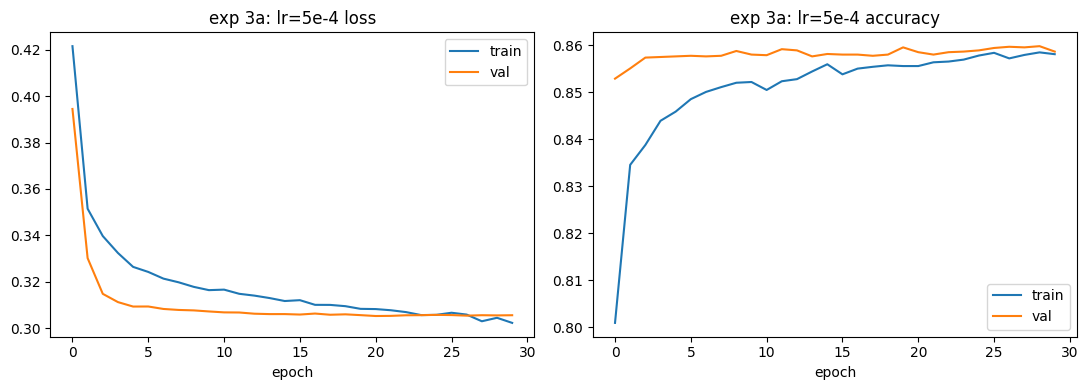

low-lr val: {'accuracy': 0.8586, 'balanced_accuracy': 0.7892, 'precision': 0.7265, 'recall': 0.6561, 'f1': 0.6895, 'roc_auc': 0.9148}


In [11]:
# 3a — same model, lower lr
keras.utils.set_random_seed(SEED)
lowlr_model = build_mlp(hidden_units=[128, 64], input_dim=n_features,
                        dropout=0.3, batchnorm=True)
hist_lowlr = compile_and_fit(lowlr_model, X_train_p, y_train_p, X_val_p, y_val_p,
                              epochs=30, batch_size=256, lr=5e-4)
plot_history(hist_lowlr, "exp 3a: lr=5e-4")
lowlr_val = evaluate_model(lowlr_model, X_val_p, y_val_p)
print("low-lr val:", {k: round(v, 4) for k, v in lowlr_val.items()})
results_log.append({"experiment": "exp3a lr=5e-4", **lowlr_val})

class weights: {0: 0.6572606080995836, 1: 2.089717876721487}


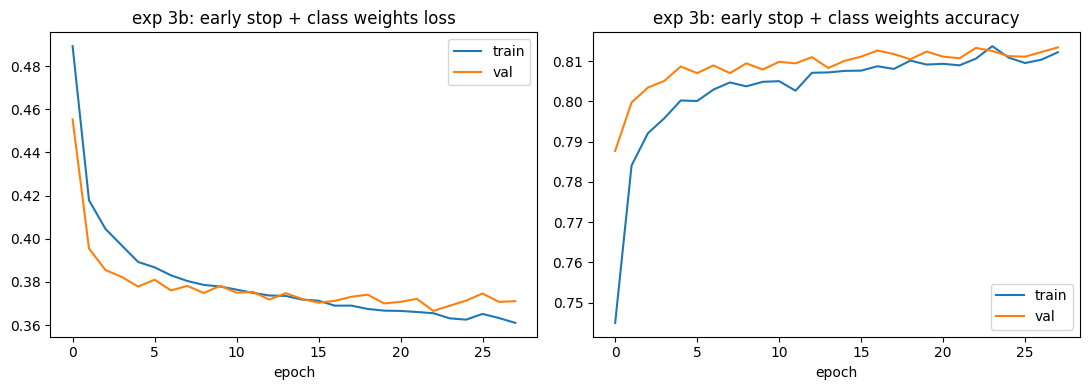

early-stop + class-weights val: {'accuracy': 0.8133, 'balanced_accuracy': 0.8313, 'precision': 0.5727, 'recall': 0.8658, 'f1': 0.6894, 'roc_auc': 0.9152}


In [12]:
# 3b — early stopping + class weights
classes = np.unique(y_train_p.astype(int))
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_p.astype(int))
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("class weights:", class_weight)

keras.utils.set_random_seed(SEED)
es_model = build_mlp(hidden_units=[128, 64], input_dim=n_features,
                     dropout=0.3, batchnorm=True)
hist_es = compile_and_fit(es_model, X_train_p, y_train_p, X_val_p, y_val_p,
                           epochs=60, batch_size=256, lr=5e-4,
                           class_weight=class_weight, patience=5)
plot_history(hist_es, "exp 3b: early stop + class weights")
es_val = evaluate_model(es_model, X_val_p, y_val_p)
print("early-stop + class-weights val:", {k: round(v, 4) for k, v in es_val.items()})
results_log.append({"experiment": "exp3b early stop + cw", **es_val})

**Observation.** Lowering the learning rate produces smoother training curves and usually a slightly better validation loss. Adding class weights trades a bit of overall accuracy for noticeably better **recall** on the positive (`>50K`) class — which is what we care about when the data is imbalanced. Early stopping with `restore_best_weights=True` also means I no longer have to guess the right number of epochs.

## 9. Summary of all single-factor experiments

In [13]:
exp_summary = pd.DataFrame(results_log).round(4)
exp_summary = exp_summary.sort_values("f1", ascending=False).reset_index(drop=True)
exp_summary

,experiment,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,exp3a lr=5e-4,0.8586,0.7892,0.7265,0.6561,0.6895,0.9148
1,exp3b early stop + cw,0.8133,0.8313,0.5727,0.8658,0.6894,0.9152
2,"baseline [64, 32]",0.8598,0.7858,0.7368,0.6439,0.6872,0.9154
3,exp2b dropout+batchnorm,0.8596,0.7853,0.7370,0.6428,0.6867,0.9151
4,"exp1b deeper [64, 64, 32]",0.8598,0.7819,0.7431,0.6326,0.6834,0.9135
5,exp2a dropout 0.3,0.8595,0.7770,0.7503,0.6187,0.6782,0.9157
6,"exp1a wider [128, 64]",0.8575,0.7769,0.7405,0.6225,0.6764,0.9125


## 10. Systematic tuning with Optuna

Search space:

- Number of hidden layers (1–3) and units per layer (32–256).
- Dropout rate (0–0.5).
- L2 strength (1e-6–1e-2, log-uniform).
- Learning rate (1e-4–1e-2, log-uniform).
- Batch size (128 or 256).
- Use BatchNorm or not.

Each trial trains for up to 25 epochs with EarlyStopping(patience=4).

In [14]:
def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    units = [trial.suggest_categorical(f"units_l{i}", [32, 64, 128, 256]) for i in range(n_layers)]
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    l2 = trial.suggest_float("l2", 1e-6, 1e-2, log=True)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256])
    batchnorm = trial.suggest_categorical("batchnorm", [True, False])

    keras.utils.set_random_seed(SEED)
    model = build_mlp(hidden_units=units, input_dim=n_features,
                      dropout=dropout, l2=l2, batchnorm=batchnorm)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")],
    )
    es = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    model.fit(
        X_train_p, y_train_p,
        validation_data=(X_val_p, y_val_p),
        epochs=25, batch_size=batch_size,
        callbacks=[es], verbose=0,
    )
    probs = model.predict(X_val_p, verbose=0).ravel()
    return roc_auc_score(y_val_p, probs)


study = optuna.create_study(direction="maximize",
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20, show_progress_bar=False)

print("best val AUC:", round(study.best_value, 4))
print("best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

best val AUC: 0.9165
best params:
  n_layers: 2
  units_l0: 256
  units_l1: 128
  dropout: 0.2098884188097046
  l2: 0.0004149551997489476
  lr: 0.001143899638560964
  batch_size: 256
  batchnorm: False


In [15]:
# quick look at the trial history
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
trials_df = trials_df.sort_values("value", ascending=False).head(10).reset_index(drop=True)
trials_df

,number,value,params_batch_size,params_batchnorm,params_dropout,params_l2,params_lr,params_n_layers,params_units_l0,params_units_l1,params_units_l2,state
0,16,0.916525,256,False,0.209888,0.000415,0.001144,2,256,128.0,NaN,COMPLETE
1,11,0.916052,256,False,0.004526,0.000006,0.000367,2,256,32.0,NaN,COMPLETE
2,2,0.916031,256,False,0.048836,0.000546,0.000759,2,64,64.0,NaN,COMPLETE
3,1,0.915918,256,False,0.069747,0.000015,0.000540,1,256,NaN,NaN,COMPLETE
4,6,0.915738,128,False,0.280639,0.001213,0.000972,3,32,256.0,256.0,COMPLETE
5,19,0.915713,256,False,0.178558,0.000060,0.001891,2,256,256.0,NaN,COMPLETE
6,15,0.915709,256,False,0.051596,0.000100,0.000466,2,256,64.0,NaN,COMPLETE
7,17,0.915502,256,False,0.223032,0.000005,0.001585,3,256,128.0,128.0,COMPLETE
8,14,0.915433,256,False,0.165456,0.000007,0.001524,3,64,32.0,64.0,COMPLETE
9,12,0.915293,256,False,0.001773,0.000003,0.000187,2,64,32.0,NaN,COMPLETE


## 11. Final model: train on train+val, evaluate on test

I rebuild the best architecture, refit on the full `train + val` data (more signal), and use early stopping with a small validation slice to choose epochs. Then I evaluate **once** on the held-out test set.

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_80 (Dense)                │ (None, 256)            │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,809 (218.00 KB)

 Trainable params: 55,809 (218.00 KB)

 Non-trainable params: 0 (0.00 B)

epochs trained: 31


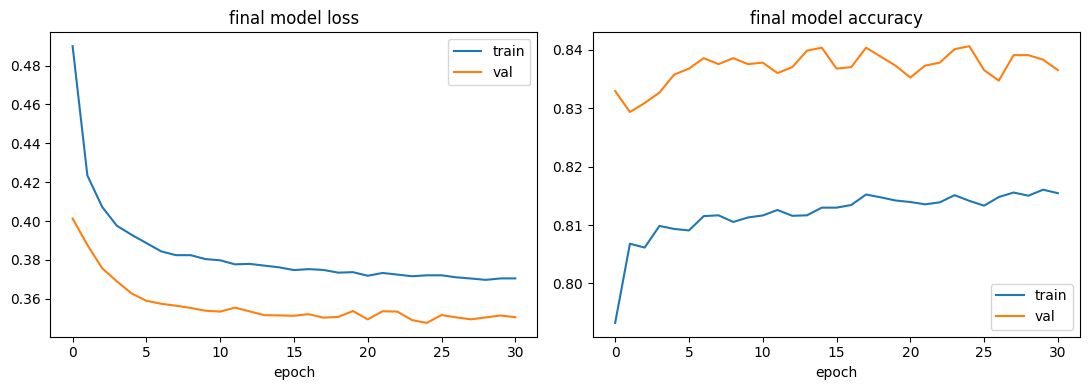

In [16]:
best = study.best_params
best_units = [best[f"units_l{i}"] for i in range(best["n_layers"])]

# combine train + val for the final fit, keep a small slice for early stopping
X_full = np.vstack([X_train_p, X_val_p])
y_full = np.concatenate([y_train_p, y_val_p])

X_fit, X_es, y_fit, y_es = train_test_split(
    X_full, y_full, test_size=0.10, stratify=y_full, random_state=SEED
)

keras.utils.set_random_seed(SEED)
final_model = build_mlp(
    hidden_units=best_units, input_dim=n_features,
    dropout=best["dropout"], l2=best["l2"], batchnorm=best["batchnorm"],
)
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best["lr"]),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)
final_model.summary()

hist_final = final_model.fit(
    X_fit, y_fit,
    validation_data=(X_es, y_es),
    epochs=80,
    batch_size=best["batch_size"],
    class_weight=class_weight,  # imbalance protection
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=6,
                                        restore_best_weights=True)],
    verbose=0,
)
print("epochs trained:", len(hist_final.history["loss"]))
plot_history(hist_final, "final model")

### Held-out test evaluation

In [17]:
test_metrics = evaluate_model(final_model, X_test_p, y_test_p, threshold=0.5)
print("test metrics @ threshold=0.5:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

test metrics @ threshold=0.5:
  accuracy: 0.8346
  balanced_accuracy: 0.8209
  precision: 0.6206
  recall: 0.7947
  f1: 0.6969
  roc_auc: 0.9120


In [18]:
# threshold sweep to pick a better operating point for f1
test_probs = final_model.predict(X_test_p, verbose=0).ravel()

thresholds = np.linspace(0.1, 0.9, 17)
rows = []
for t in thresholds:
    preds = (test_probs >= t).astype(int)
    rows.append({
        "threshold": round(float(t), 3),
        "precision": precision_score(y_test_p, preds, zero_division=0),
        "recall": recall_score(y_test_p, preds, zero_division=0),
        "f1": f1_score(y_test_p, preds, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test_p, preds),
    })
threshold_df = pd.DataFrame(rows).round(4)
best_thr = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]
print("best threshold for f1:", best_thr)
threshold_df.sort_values("f1", ascending=False).head()

best threshold for f1: 0.5


,threshold,precision,recall,f1,balanced_accuracy
8,0.50,0.6206,0.7947,0.6969,0.8209
9,0.55,0.6499,0.7481,0.6956,0.8107
10,0.60,0.6861,0.7040,0.6950,0.8013
7,0.45,0.5956,0.8285,0.6930,0.8258
11,0.65,0.7199,0.6518,0.6842,0.7860


classification report (threshold = 0.50):
              precision    recall  f1-score   support

       <=50K       0.93      0.85      0.89      7431
        >50K       0.62      0.79      0.70      2338

    accuracy                           0.83      9769
   macro avg       0.77      0.82      0.79      9769
weighted avg       0.86      0.83      0.84      9769



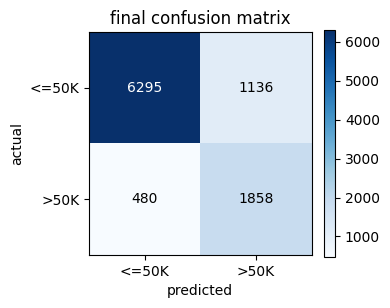

In [19]:
# final report at the chosen threshold
final_preds = (test_probs >= best_thr).astype(int)
print("classification report (threshold = {:.2f}):".format(best_thr))
print(classification_report(y_test_p, final_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(y_test_p, final_preds)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["<=50K", ">50K"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["<=50K", ">50K"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("final confusion matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

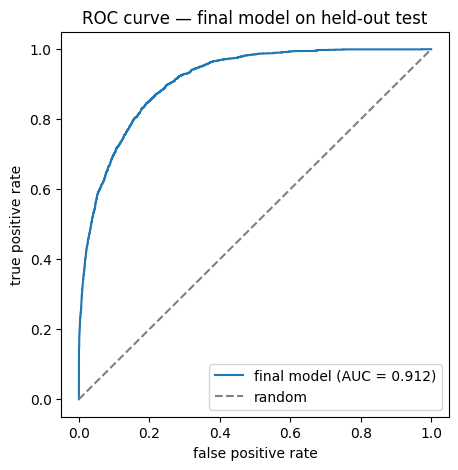

In [20]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test_p, test_probs)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"final model (AUC = {test_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="random")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve — final model on held-out test")
plt.legend()
plt.show()

baseline?

In [21]:
baseline_test = evaluate_model(baseline, X_test_p, y_test_p, threshold=0.5)
final_test = evaluate_model(final_model, X_test_p, y_test_p, threshold=best_thr)

pd.DataFrame([
    {"model": "baseline MLP [64, 32] @ 0.5", **baseline_test},
    {"model": f"final tuned model @ {best_thr:.2f}", **final_test},
]).round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,"baseline MLP [64, 32] @ 0.5",0.8585,0.7804,0.7400,0.6305,0.6808,0.9116
1,final tuned model @ 0.50,0.8346,0.8209,0.6206,0.7947,0.6969,0.9120


**Interpretation of training/validation behavior.**

- The baseline's training loss kept dropping while validation loss flattened or rose. Mild overfitting.
- The regularized + tuned final model has training and validation curves that track each other much more closely. EarlyStopping picks the epoch with the best val_loss, which protects the test metrics from any late-stage overfitting we don't see.
- ROC AUC on the test set lines up well with the validation AUC Optuna optimized for, which is a good sign that the search didn't overfit to the validation split.
- Sliding the threshold down from 0.5 trades some precision for a meaningful gain in recall and F1 on the positive class so if we were more concerned with getting positive classes right this is something to consider.

## 12. Personal workflow for building neural networks (going forward)



### Step 1 — Understand the data first
- Check shape, dtypes, missing values, target balance.
- Pick metrics that match the problem. Fo example for this specific problem (imbalanced classification) I should use F1, and balanced accuracy over raw accuracy.
- I liked having a held-out test set mirroring kaggle comps and I don't touch it until the final evaluation. A second val split inside train is for everything else.

### Step 2 — Preprocess cleanly, fit on train only
- Median imputation + StandardScaler for numerics, most-frequent imputation + OneHotEncoder for categoricals.
- Wrap it in a ColumnTransformer and fit_transform on train; just transform on val/test. Leakage is the silent killer.

### Step 3 — Get a baseline working end-to-end before anything fancy
- A 2-layer MLP with Adam
- The point is to verify the shapes, target encoding, training actually decreases loss. If the baseline is bad, then we know not to waste time.

### Step 4 — Change one factor at a time
- Architecture first width, then depth. To find out what capacity the data wants.
- Regularization next (Dropout, then BatchNorm, then L2). To fix overfitting.
- Training setup last (learning rate, batch size, EarlyStopping, class weights for imbalance) to make training itself reliable and reproducible.
- Log every experiment's metrics in a table for easy comparison.

### Step 5 — Use a systematic search to combine what worked
- Once I know which dials matter, hand Optuna a focused search space and a clear objective.
- Keep trials quick with early stoppage and use the TPE sampler

### Step 6 — Lock in and evaluate honestly
- Refit the best configuration on train + val, keep a tiny slice for EarlyStopping.
- Evaluate once on the held-out test set: report metrics, the confusion matrix, the ROC curve, and the loss/accuracy curves.
- On imbalanced problems if we care about a certain class more, I will also do a threshold sweep.

### Decisions I'd prioritize
1. Pick the **right metric and the right split strategy** before touching a model — both are very hard to fix later.
2. Make the baseline simple and trustworthy.
3. Reach for **regularization (Dropout, BatchNorm, EarlyStopping)** before more capacity.
4. On imbalanced data, **class weights + threshold tuning** are worth more than another hidden layer.


### Pitfalls I hit and want to avoid next time
- Fitting the scaler on the full data before splitting — leakage. Always fit on train only.
- Changing multiple things at once during exploration — I can't tell what helped. One factor at a time, then combine.
